# Z24 dataset - visual exploration

Explores `Z24-dataset-processed/inputs.npy` (1530 samples x 27 accelerometer channels x 6000 time steps,
17 damage scenarios) and what happens when a sample is shortened with `--seq_len` in `run_prism_z24.py`:
**crop** (keep the first N points, same sample rate, shorter duration) vs **downsample** (N points spanning
the full duration, lower sample rate). Run top to bottom; needs `inputs.npy`/`labels.npy` in
`Z24-dataset-processed/` next to this notebook (see the main README to fetch them).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

DATA_DIR = "Z24-dataset-processed"
X = np.load(f"{DATA_DIR}/inputs.npy")   # (1530, 27, 6000)
y = np.load(f"{DATA_DIR}/labels.npy")   # (1530,)
FS = 100.0  # sampling rate is not stated in the dataset card; adjust if you know the true value

idx = np.arange(len(y))
setup = (idx % 90) // 10
segment = idx % 10

print("inputs", X.shape, X.dtype, "| labels", y.shape, y.dtype)
print("scenarios (labels):", np.unique(y))
print("value range: [{:.4f}, {:.4f}]  mean {:.2e}  std {:.2e}".format(X.min(), X.max(), X.mean(), X.std()))

inputs (1530, 27, 6000) float32 | labels (1530,) int64
scenarios (labels): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


value range: [-0.0177, 0.4387]  mean 9.77e-05  std 7.50e-03


## 1. Label distribution

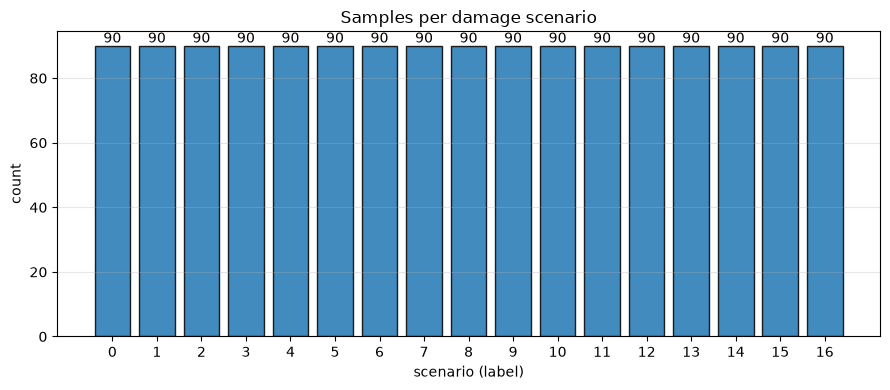

In [2]:
labels, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, counts, color="tab:blue", alpha=0.85, edgecolor="black")
ax.bar_label(bars)
ax.set(title="Samples per damage scenario", xlabel="scenario (label)", ylabel="count",
       xticks=labels)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

## 2. Raw signals: one sample, several channels

The dataset has huge spikes (see the diagnostics in earlier sessions: some samples have a peak beyond
30x their own std), so a single sample can look mostly flat with rare bursts - that's the data, not a bug.

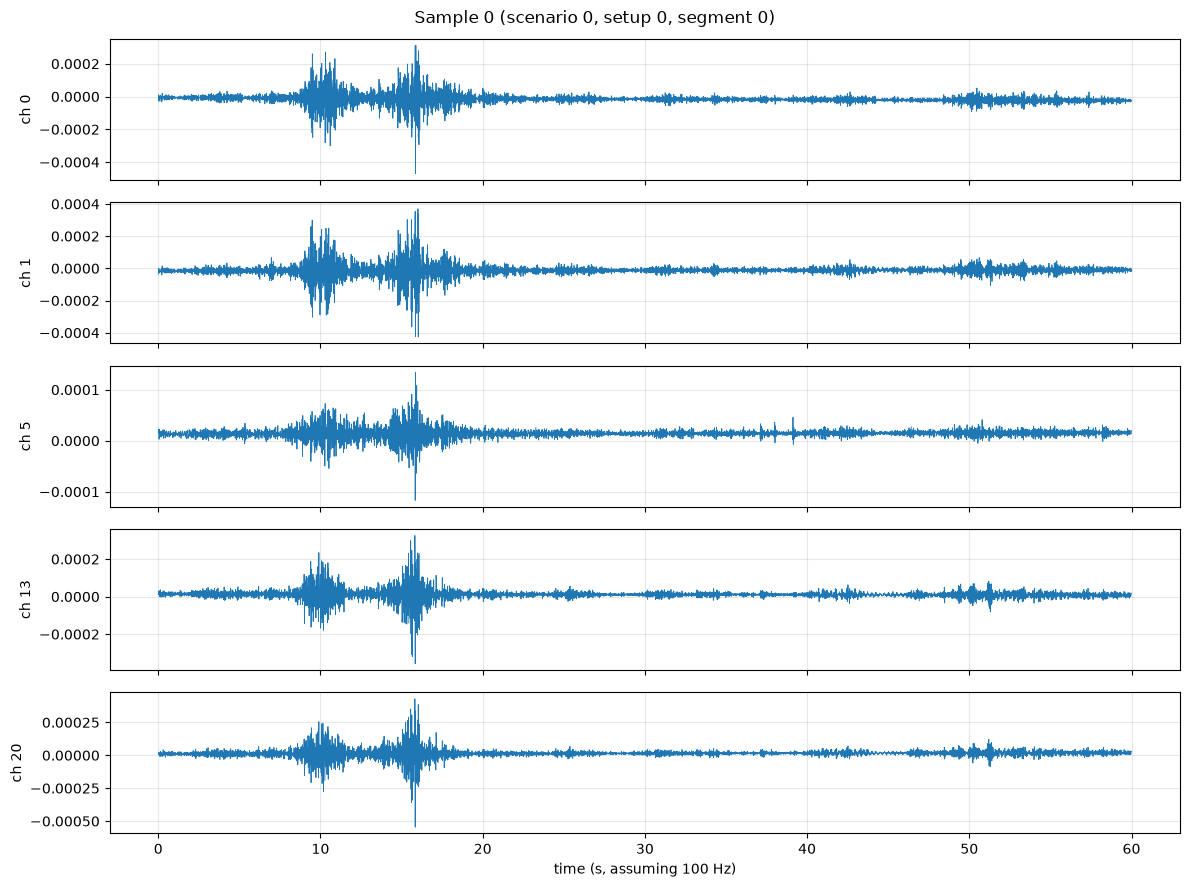

In [3]:
sample = 0
chans = [0, 1, 5, 13, 20]
t = np.arange(X.shape[2]) / FS
fig, axes = plt.subplots(len(chans), 1, figsize=(12, 9), sharex=True)
for a, c in zip(axes, chans):
    a.plot(t, X[sample, c], lw=0.6, color="tab:blue")
    a.set_ylabel(f"ch {c}")
    a.grid(alpha=0.3)
axes[-1].set_xlabel("time (s, assuming {:.0f} Hz)".format(FS))
fig.suptitle(f"Sample {sample} (scenario {y[sample]}, setup {setup[sample]}, segment {segment[sample]})")
fig.tight_layout()

## 3. Cropping vs downsampling to `--seq_len 1000`

Same logic as `run_prism_z24.py --seq_len 1000 --seq_mode {crop,downsample}`:
- **crop**: keep the first 1000 points (10 s at 100 Hz) - full resolution, shorter duration.
- **downsample**: 1000 points evenly spaced over the full 6000 - full duration, 1/6 the sample rate.
  Any frequency content above the new Nyquist limit (fs/12 instead of fs/2) folds back (aliases) onto
  lower frequencies instead of disappearing cleanly.

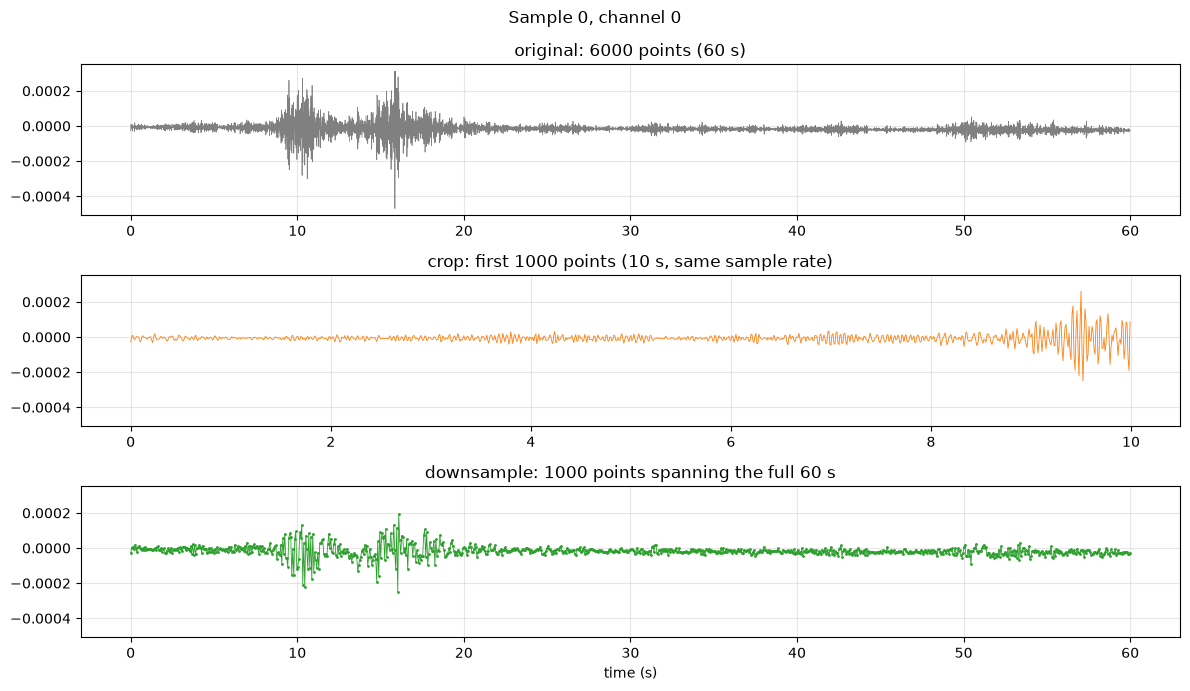

In [4]:
N_SHORT = 1000
sig = X[sample, 0]
cropped = sig[:N_SHORT]
ds_idx = np.linspace(0, len(sig) - 1, N_SHORT).round().astype(int)
downsampled = sig[ds_idx]

fig, ax = plt.subplots(3, 1, figsize=(12, 7), sharey=True)
ax[0].plot(np.arange(len(sig)) / FS, sig, lw=0.5, color="gray")
ax[0].set_title(f"original: {len(sig)} points ({len(sig)/FS:.0f} s)")
ax[1].plot(np.arange(len(cropped)) / FS, cropped, lw=0.6, color="tab:orange")
ax[1].set_title(f"crop: first {N_SHORT} points ({N_SHORT/FS:.0f} s, same sample rate)")
ax[2].plot(ds_idx / FS, downsampled, lw=0.6, color="tab:green", marker=".", ms=2)
ax[2].set_title(f"downsample: {N_SHORT} points spanning the full {len(sig)/FS:.0f} s")
for a in ax:
    a.grid(alpha=0.3)
ax[-1].set_xlabel("time (s)")
fig.suptitle(f"Sample {sample}, channel 0")
fig.tight_layout()

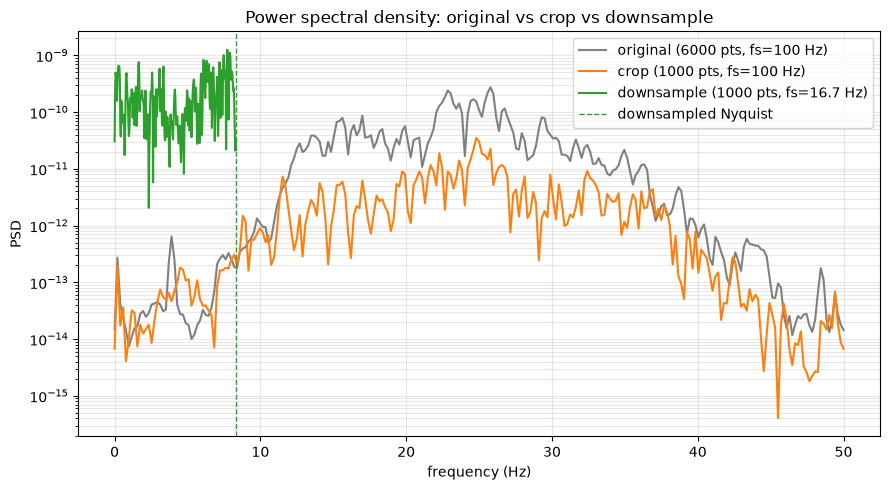

In [5]:
# Power spectral density: downsampling folds high-frequency energy back (aliasing), cropping does not -
# it only loses low-frequency resolution because the window is shorter.
f_o, P_o = welch(sig, fs=FS, nperseg=512)
f_c, P_c = welch(cropped, fs=FS, nperseg=min(512, len(cropped)))
f_d, P_d = welch(downsampled, fs=FS / 6, nperseg=min(512, len(downsampled)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(f_o, P_o, label=f"original ({len(sig)} pts, fs={FS:.0f} Hz)", color="gray")
ax.semilogy(f_c, P_c, label=f"crop ({N_SHORT} pts, fs={FS:.0f} Hz)", color="tab:orange")
ax.semilogy(f_d, P_d, label=f"downsample ({N_SHORT} pts, fs={FS/6:.1f} Hz)", color="tab:green")
ax.axvline(FS / 12, color="tab:green", ls="--", lw=1, label="downsampled Nyquist")
ax.set(title="Power spectral density: original vs crop vs downsample",
       xlabel="frequency (Hz)", ylabel="PSD")
ax.legend()
ax.grid(alpha=0.3, which="both")
fig.tight_layout()

## 4. Average signal per damage scenario

Averaging over samples of the same scenario should cancel out random noise/spikes and reveal any
systematic difference between scenarios, if one is visible in the time domain at all.

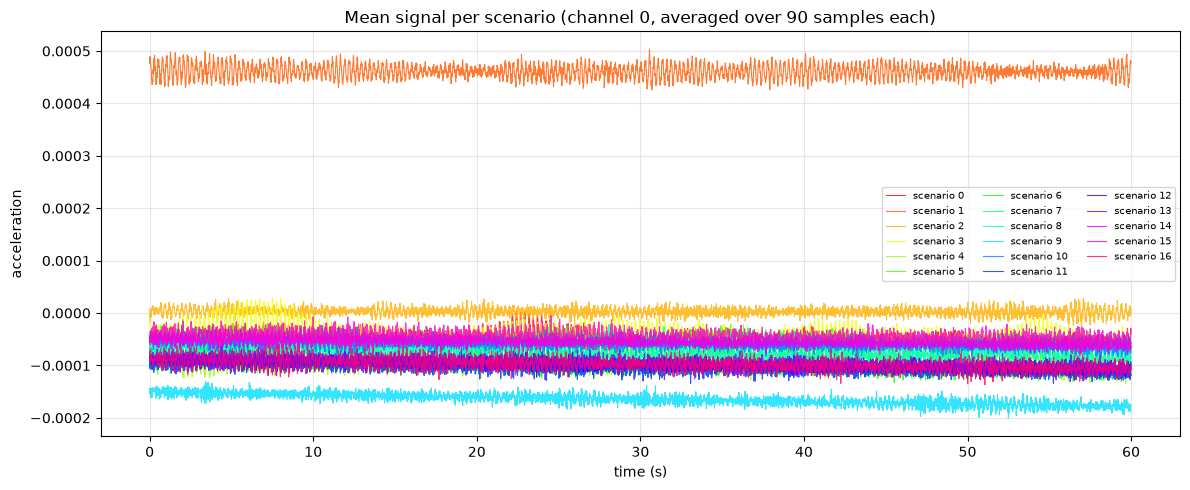

In [6]:
channel = 0
fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.cm.hsv(np.linspace(0, 1, 17, endpoint=False))
for c in range(17):
    avg = X[y == c, channel].mean(axis=0)
    ax.plot(t, avg, lw=0.8, color=cmap[c], label=f"scenario {c}", alpha=0.8)
ax.set(title=f"Mean signal per scenario (channel {channel}, averaged over {counts[0]} samples each)",
       xlabel="time (s)", ylabel="acceleration")
ax.legend(fontsize=7, ncol=3)
ax.grid(alpha=0.3)
fig.tight_layout()

## 5. t-SNE of spectral features, coloured by scenario and by setup

Log-Welch-PSD features (pooled to 64 bins per channel) fed to Logistic Regression reached ~97% test
accuracy under the (leaky) `segment` split but only ~42% under the strict `setup` split - and the same
features predict the *setup* itself with 100% accuracy. The plot below shows why: colour by scenario
looks mixed, colour by setup shows much clearer clusters, i.e. the measurement setup changes the signal
more than the damage scenario does.

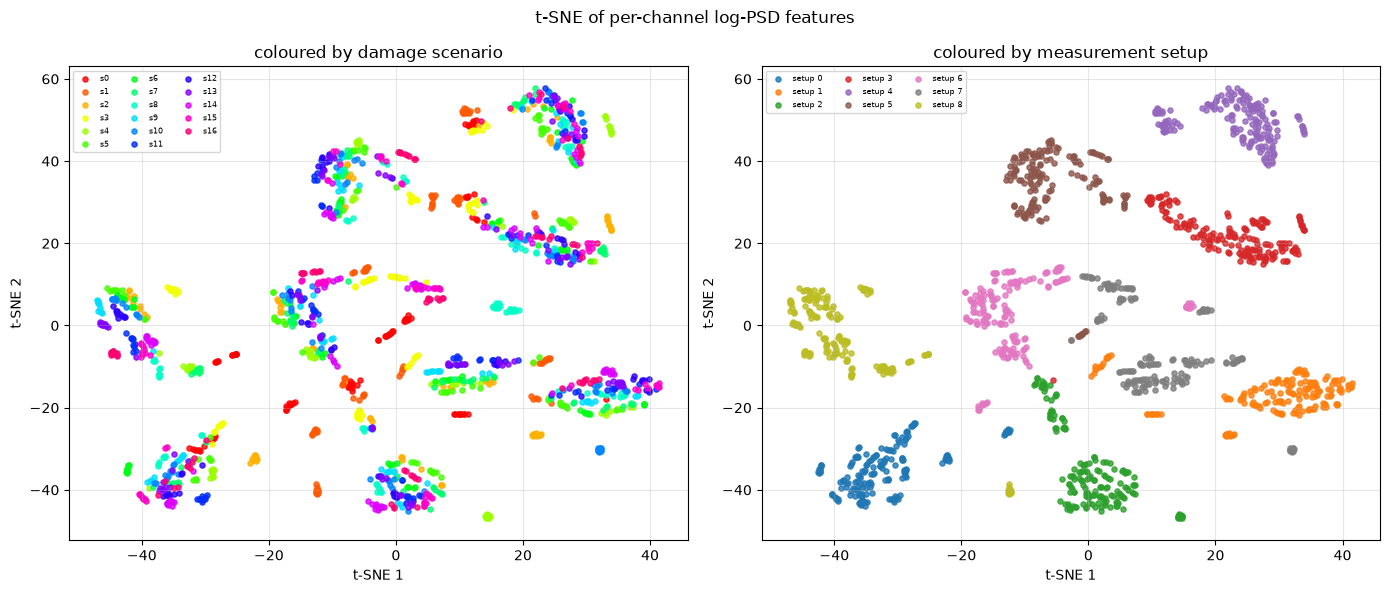

In [7]:
from sklearn.manifold import TSNE

f, P = welch(X, fs=FS, nperseg=512, axis=-1)
P = np.log(P[:, :, :256] + 1e-20).reshape(len(y), X.shape[1], 64, 4).mean(-1)  # (N, C, 64 bins)
F = P.reshape(len(y), -1)

z2 = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=0).fit_transform(F)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for c in range(17):
    m = y == c
    ax[0].scatter(z2[m, 0], z2[m, 1], s=14, color=cmap[c], label=f"s{c}", alpha=0.8)
ax[0].set_title("coloured by damage scenario")
scol = plt.cm.tab10(np.arange(9) % 10)
for s in range(9):
    m = setup == s
    ax[1].scatter(z2[m, 0], z2[m, 1], s=14, color=scol[s], label=f"setup {s}", alpha=0.8)
ax[1].set_title("coloured by measurement setup")
for a in ax:
    a.set(xlabel="t-SNE 1", ylabel="t-SNE 2")
    a.legend(fontsize=6, ncol=3)
    a.grid(alpha=0.3)
fig.suptitle("t-SNE of per-channel log-PSD features")
fig.tight_layout()

## Where `--seq_len` fits in

`run_prism_z24.py --seq_len N --seq_mode {crop,downsample}` applies exactly the transform shown in
section 3 before training, e.g.:

```bash
python run_prism_z24.py --model transformer --split setup --seq_len 1000 --seq_mode crop
```

Given the mean-signal plot above, if damage mainly shows up as a shift in resonant frequency, `downsample`
risks aliasing that shift away unless the new sample rate is still well above twice the highest frequency
that matters; `crop` is safer for that reason but throws away part of the recording instead.